In [14]:
!pip install xgboost scikit-learn matplotlib


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import requests
import json
import pandas as pd
from datetime import datetime
import os
from dotenv import load_dotenv

load_dotenv()

client_id = os.getenv('SH_ID') 
client_secret = os.getenv('SH_SECRET') 

print("Pobieranie tokenu dostępu...")
auth_response = requests.post(
    "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token",
    data={
        "grant_type": "client_credentials",
        "client_id": client_id,
        "client_secret": client_secret
    }
)
token = auth_response.json().get("access_token")

url = "https://sh.dataspace.copernicus.eu/api/v1/statistics"
headers = {
    "Authorization": f"Bearer {token}",
    "Accept": "application/json",
    "Content-Type": "application/json"
}

evalscript = """
//VERSION=3
function setup() {
  return {
    input: ["B04", "B08", "SCL", "dataMask"],
    output: [
      { id: "ndvi", bands: 1 },
      { id: "dataMask", bands: 1 }
    ]
  };
}

function evaluatePixel(samples) {
  // Ignorujemy chmury i cienie (klasy SCL: 3, 8, 9, 10)
  if ([3, 8, 9, 10].includes(samples.SCL) || samples.dataMask === 0) {
      return { ndvi: [NaN], dataMask: [0] };
  }
  let ndvi = (samples.B08 - samples.B04) / (samples.B08 + samples.B04);
  return { ndvi: [ndvi], dataMask: [1] };
}
"""
payload = {
  "input": {
    "bounds": {
      "bbox": [16.90, 51.05, 17.15, 51.15]
    },
    "data": [
      {
        "type": "sentinel-2-l2a",
        "dataFilter": { "mosaickingOrder": "leastCC" }
      }
    ]
  },
  "aggregation": {
    "timeRange": {
      "from": "2025-10-01T00:00:00Z", 
      "to": "2026-04-24T00:00:00Z"
    },
    "aggregationInterval": { "of": "P5D" }, 
    "evalscript": evalscript,
    "resx": 0.0005,
    "resy": 0.0005
  }
}

print("Przeliczanie historii NDVI w chmurze CDSE. To potrwa kilka sekund...")
response = requests.post(url, headers=headers, json=payload)

if response.status_code == 200:
    data = response.json()
    wyniki = []
    
    for item in data['data']:
        data_odczytu = item['interval']['from'][:10]

        statystyki = item['outputs']['ndvi']['bands']['B0']['stats']
        
        if statystyki['sampleCount'] > 0:
            wyniki.append({
                "Data": data_odczytu,
                "Srednie_NDVI": statystyki['mean'],
                "Min_NDVI": statystyki['min'],
                "Max_NDVI": statystyki['max']
            })
            
    df = pd.DataFrame(wyniki)
    print("✅ SUKCES! Pobrano szereg czasowy.")
    display(df.tail())
else:
    print(f"❌ BŁĄD {response.status_code}: {response.text}")

Pobieranie tokenu dostępu...
Przeliczanie historii NDVI w chmurze CDSE. To potrwa kilka sekund...
✅ SUKCES! Pobrano szereg czasowy.


,Data,Srednie_NDVI,Min_NDVI,Max_NDVI
36,2026-03-30,0.323108,-1.0,0.962797
37,2026-04-04,0.333479,-1.0,0.930364
38,2026-04-09,0.370325,-1.0,1.0
39,2026-04-14,0.28127,-1.0,0.889046
40,2026-04-19,0.422123,-1.0,1.0


In [16]:
import requests
import pandas as pd
from datetime import datetime
import os
from dotenv import load_dotenv

def bezpieczne_zaokraglenie(wartosc, miejsca_po_przecinku=3):
    try:
        # Próbujemy zamienić na liczbę i zaokrąglić
        return round(float(wartosc), miejsca_po_przecinku)
    except (ValueError, TypeError):
        # Jeśli się nie da (bo to np. pusty string lub None), zwracamy NaN z biblioteki pandas
        return pd.NA

def wygeneruj_siatke(bbox, krok_w_stopniach):
    """
    Dzieli duży BBOX na mniejsze sektory (kratki) o podanym rozmiarze w stopniach.
    """
    min_x, min_y, max_x, max_y = bbox
    sektory = []
    id_sektora = 1
    
    curr_x = min_x
    while curr_x < max_x:
        next_x = min(curr_x + krok_w_stopniach, max_x)
        curr_y = min_y
        while curr_y < max_y:
            next_y = min(curr_y + krok_w_stopniach, max_y)
            sektory.append({
                "ID_Sektora": f"Sektor_{id_sektora}",
                "bbox": [curr_x, curr_y, next_x, next_y]
            })
            id_sektora += 1
            curr_y = next_y
        curr_x = next_x
        
    return sektory

def pobierz_dane_z_satelity(start_date, end_date, bbox, rozmiar_kratki_stopnie=0.05):
    """
    Pobiera szereg czasowy NDVI dla siatki podzielonej na mniejsze sektory.
    rozmiar_kratki_stopnie = 0.01 to około 1x1 km.
    """
    load_dotenv()
    client_id = os.getenv('SH_ID') 
    client_secret = os.getenv('SH_SECRET') 

    # 1. Pobranie tokenu
    print("🔑 Pobieranie tokenu dostępu...")
    auth_response = requests.post(
        "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token",
        data={"grant_type": "client_credentials", "client_id": client_id, "client_secret": client_secret}
    )
    if auth_response.status_code != 200:
        raise Exception("Błąd autoryzacji. Sprawdź SH_ID i SH_SECRET.")
    token = auth_response.json().get("access_token")

    url = "https://sh.dataspace.copernicus.eu/api/v1/statistics"
    headers = {
        "Authorization": f"Bearer {token}",
        "Accept": "application/json",
        "Content-Type": "application/json"
    }

    evalscript = """
    //VERSION=3
    function setup() {
      return { input: ["B04", "B08", "SCL", "dataMask"], output: [ { id: "ndvi", bands: 1 }, { id: "dataMask", bands: 1 } ] };
    }
    function evaluatePixel(samples) {
      if ([3, 8, 9, 10].includes(samples.SCL) || samples.dataMask === 0) {
          return { ndvi: [NaN], dataMask: [0] };
      }
      let ndvi = (samples.B08 - samples.B04) / (samples.B08 + samples.B04);
      return { ndvi: [ndvi], dataMask: [1] };
    }
    """

    # 2. Podział na siatkę
    sektory = wygeneruj_siatke(bbox, krok_w_stopniach=rozmiar_kratki_stopnie)
    print(f"🗺️ Podzielono obszar na {len(sektory)} mniejszych sektorów.")

    wszystkie_wyniki = []

    # 3. Pętla po sektorach (wysyłanie zapytań dla każdej "kratki")
    for sektor in sektory:
        print(f"⏳ Pobieranie danych dla {sektor['ID_Sektora']}...")
        
        payload = {
          "input": {
            "bounds": {"bbox": sektor['bbox']},
            "data": [{"type": "sentinel-2-l2a", "dataFilter": { "mosaickingOrder": "leastCC" }}]
          },
          "aggregation": {
            "timeRange": {"from": start_date, "to": end_date},
            "aggregationInterval": { "of": "P5D" }, 
            "evalscript": evalscript,
            "resx": 0.0005,
            "resy": 0.0005
          }
        }

        response = requests.post(url, headers=headers, json=payload)

        if response.status_code == 200:
            data = response.json()
            for item in data['data']:
                data_odczytu = item['interval']['from'][:10]
                statystyki = item['outputs']['ndvi']['bands']['B0']['stats']
                
                # Zapisujemy tylko daty, w których satelita "coś widział" (sampleCount > 0)
                if statystyki['sampleCount'] > 0:
                    wszystkie_wyniki.append({
                        "Data": data_odczytu,
                        "Obszar": sektor['ID_Sektora'],
                        "Wspolrzedne_Sektora": str(sektor['bbox']),
                        # Zmiana tutaj:
                        "Srednie_NDVI": bezpieczne_zaokraglenie(statystyki['mean']),
                        "Min_NDVI": bezpieczne_zaokraglenie(statystyki['min']),
                        "Max_NDVI": bezpieczne_zaokraglenie(statystyki['max'])
                    })
        else:
            print(f"❌ BŁĄD dla {sektor['ID_Sektora']}: {response.text}")

    # 4. Zwrot gotowej tabeli
    df = pd.DataFrame(wszystkie_wyniki)
    print("\n✅ SUKCES! Proces zakończony.")
    return df

# ==========================================
# UŻYCIE FUNKCJI
# ==========================================
if __name__ == "__main__":
    # Parametry wejściowe
    poczatek = "2025-10-01T00:00:00Z"
    koniec = "2026-04-24T00:00:00Z"
    moj_bbox = [16.90, 51.05, 17.00, 51.10] # Zmniejszyłem lekko BBOX dla testów
    
    # Krok 0.02 stopnia to kwadraty ok. 2km x 2km. 
    # Ustaw na 0.01 jeśli chcesz gęstszą siatkę (~1x1km).
    rozmiar = 0.02 

    # Wywołanie
    moje_dane_df = pobierz_dane_z_satelity(
        start_date=poczatek, 
        end_date=koniec, 
        bbox=moj_bbox, 
        rozmiar_kratki_stopnie=rozmiar
    )

    # Posortowanie danych dla czytelności (najpierw po obszarze, potem po dacie)
    if not moje_dane_df.empty:
        moje_dane_df = moje_dane_df.sort_values(by=["Obszar", "Data"]).reset_index(drop=True)
        display(moje_dane_df)
    else:
        print("Nie znaleziono żadnych bezchmurnych danych w tym przedziale.")

🔑 Pobieranie tokenu dostępu...
🗺️ Podzielono obszar na 18 mniejszych sektorów.
⏳ Pobieranie danych dla Sektor_1...
⏳ Pobieranie danych dla Sektor_2...
⏳ Pobieranie danych dla Sektor_3...
⏳ Pobieranie danych dla Sektor_4...
⏳ Pobieranie danych dla Sektor_5...
⏳ Pobieranie danych dla Sektor_6...
⏳ Pobieranie danych dla Sektor_7...
⏳ Pobieranie danych dla Sektor_8...
⏳ Pobieranie danych dla Sektor_9...
⏳ Pobieranie danych dla Sektor_10...
⏳ Pobieranie danych dla Sektor_11...
⏳ Pobieranie danych dla Sektor_12...
⏳ Pobieranie danych dla Sektor_13...
⏳ Pobieranie danych dla Sektor_14...
⏳ Pobieranie danych dla Sektor_15...
⏳ Pobieranie danych dla Sektor_16...
⏳ Pobieranie danych dla Sektor_17...
⏳ Pobieranie danych dla Sektor_18...

✅ SUKCES! Proces zakończony.


,Data,Obszar,Wspolrzedne_Sektora,Srednie_NDVI,Min_NDVI,Max_NDVI
0,2025-10-01,Sektor_1,"[16.9, 51.05, 16.919999999999998, 51.07]",NaN,NaN,NaN
1,2025-10-06,Sektor_1,"[16.9, 51.05, 16.919999999999998, 51.07]",NaN,NaN,NaN
2,2025-10-11,Sektor_1,"[16.9, 51.05, 16.919999999999998, 51.07]",NaN,NaN,NaN
3,2025-10-16,Sektor_1,"[16.9, 51.05, 16.919999999999998, 51.07]",0.438,-0.679,0.945
4,2025-10-21,Sektor_1,"[16.9, 51.05, 16.919999999999998, 51.07]",NaN,NaN,NaN
...,...,...,...,...,...,...
730,2026-03-30,Sektor_9,"[16.939999999999998, 51.09, 16.959999999999997...",0.314,-0.084,0.909
731,2026-04-04,Sektor_9,"[16.939999999999998, 51.09, 16.959999999999997...",NaN,NaN,NaN
732,2026-04-09,Sektor_9,"[16.939999999999998, 51.09, 16.959999999999997...",0.271,-0.015,0.608
733,2026-04-14,Sektor_9,"[16.939999999999998, 51.09, 16.959999999999997...",0.189,0.139,0.285


In [17]:
# Tworzymy tabelę przestawną
df_pivot = moje_dane_df.pivot_table(
    index="Obszar",       # Wiersze: nasze sektory
    columns="Data",       # Kolumny: kolejne dni
    values="Srednie_NDVI" # Wartości w środku: Średnie NDVI (możesz zmienić np. na Max_NDVI)
)

# Wypełniamy puste miejsca (gdzie były chmury i brak danych w danym dniu) wartością NaN
# lub możemy wpisać np. słowo "Brak", aby tabela była czytelniejsza
df_pivot = df_pivot.fillna("Chmury/Brak")

print("Zestawienie średniego NDVI (Sektory vs Dni):")
display(df_pivot)

Zestawienie średniego NDVI (Sektory vs Dni):


Data,2025-10-01,2025-10-16,2025-10-21,2025-10-26,2025-10-31,2025-11-05,2025-11-10,2025-11-25,2025-12-05,2025-12-10,...,2026-03-05,2026-03-10,2026-03-15,2026-03-20,2026-03-25,2026-03-30,2026-04-04,2026-04-09,2026-04-14,2026-04-19
Obszar,,,,,,,,,,,,,,,,,,,,,
Sektor_1,Chmury/Brak,0.438,Chmury/Brak,0.258,0.427,0.418,Chmury/Brak,Chmury/Brak,0.13,0.409,...,0.298,0.349,0.235,0.334,0.267,0.395,0.405,0.418,0.337,0.491
Sektor_10,Chmury/Brak,0.386,-0.077,0.223,0.379,0.380,0.205,Chmury/Brak,Chmury/Brak,0.340,...,0.248,-0.013,Chmury/Brak,0.268,0.266,0.294,0.34,0.328,0.191,0.388
Sektor_11,Chmury/Brak,0.523,Chmury/Brak,0.431,0.539,0.531,0.301,Chmury/Brak,Chmury/Brak,0.497,...,0.368,Chmury/Brak,Chmury/Brak,0.335,0.323,0.428,0.415,0.407,0.242,0.527
Sektor_12,Chmury/Brak,0.525,Chmury/Brak,0.111,0.483,0.481,0.32,Chmury/Brak,Chmury/Brak,0.424,...,0.306,-0.105,Chmury/Brak,Chmury/Brak,0.213,0.351,Chmury/Brak,0.396,Chmury/Brak,0.467
Sektor_13,Chmury/Brak,0.517,Chmury/Brak,0.375,0.429,0.425,0.193,Chmury/Brak,Chmury/Brak,0.367,...,0.267,0.099,Chmury/Brak,0.291,0.282,0.330,0.341,0.344,0.302,0.425
Sektor_14,0.236,0.432,Chmury/Brak,0.195,0.489,0.487,Chmury/Brak,Chmury/Brak,Chmury/Brak,0.431,...,0.329,Chmury/Brak,Chmury/Brak,0.33,0.384,0.374,0.452,0.43,0.32,0.495
Sektor_15,0.331,0.391,Chmury/Brak,0.083,0.345,0.351,0.198,Chmury/Brak,Chmury/Brak,0.295,...,0.231,0.008,Chmury/Brak,0.004,0.286,0.278,0.222,0.396,Chmury/Brak,0.376
Sektor_2,Chmury/Brak,0.449,Chmury/Brak,0.155,0.493,0.406,Chmury/Brak,Chmury/Brak,Chmury/Brak,0.379,...,0.291,0.137,Chmury/Brak,Chmury/Brak,0.237,0.343,0.351,0.418,0.353,0.435
Sektor_3,Chmury/Brak,0.722,Chmury/Brak,0.143,Chmury/Brak,0.632,Chmury/Brak,Chmury/Brak,Chmury/Brak,0.508,...,0.339,Chmury/Brak,Chmury/Brak,0.298,0.336,0.426,0.365,Chmury/Brak,0.561,0.588


In [18]:
import numpy as np

# KROK 1: Przygotowanie danych
# Zamieniamy tekst "Chmury/Brak" na faktyczne braki danych (NaN) i wymuszamy typ liczbowy
df_num = df_pivot.replace("Chmury/Brak", np.nan).astype(float)

# KROK 2: Podejście 1 - "Dni obok" (Interpolacja liniowa)
# axis=1 oznacza, że idziemy po kolumnach (datach) dla każdego wiersza (sektora) z osobna.
# limit_direction='both' sprawia, że łatamy dziury zarówno w środku, jak i na brzegach.
df_uzupelnione = df_num.interpolate(method='linear', axis=1, limit_direction='both')

# KROK 3: Podejście 2 - "Przestrzeń obok" (Średnia z całego obszaru)
# Może się zdarzyć, że nad CAŁYM sektorem były chmury przez bardzo długi czas 
# i interpolacja sobie nie poradziła. Wtedy wpisujemy tam średnią wartość NDVI 
# wyliczoną z POZOSTAŁYCH sektorów w dokładnie ten sam dzień.
srednia_z_dnia = df_num.mean() # to liczy średnią dla każdej kolumny (daty)
df_uzupelnione = df_uzupelnione.fillna(srednia_z_dnia)

print("Tabela po uzupełnieniu chmur:")
display(df_uzupelnione.round(3))

Tabela po uzupełnieniu chmur:


Data,2025-10-01,2025-10-16,2025-10-21,2025-10-26,2025-10-31,2025-11-05,2025-11-10,2025-11-25,2025-12-05,2025-12-10,...,2026-03-05,2026-03-10,2026-03-15,2026-03-20,2026-03-25,2026-03-30,2026-04-04,2026-04-09,2026-04-14,2026-04-19
Obszar,,,,,,,,,,,,,,,,,,,,,
Sektor_1,0.438,0.438,0.348,0.258,0.427,0.418,0.322,0.226,0.130,0.409,...,0.298,0.349,0.235,0.334,0.267,0.395,0.405,0.418,0.337,0.491
Sektor_10,0.386,0.386,-0.077,0.223,0.379,0.380,0.205,0.250,0.295,0.340,...,0.248,-0.013,0.128,0.268,0.266,0.294,0.340,0.328,0.191,0.388
Sektor_11,0.523,0.523,0.477,0.431,0.539,0.531,0.301,0.366,0.432,0.497,...,0.368,0.357,0.346,0.335,0.323,0.428,0.415,0.407,0.242,0.527
Sektor_12,0.525,0.525,0.318,0.111,0.483,0.481,0.320,0.355,0.389,0.424,...,0.306,-0.105,0.001,0.107,0.213,0.351,0.374,0.396,0.432,0.467
Sektor_13,0.517,0.517,0.446,0.375,0.429,0.425,0.193,0.251,0.309,0.367,...,0.267,0.099,0.195,0.291,0.282,0.330,0.341,0.344,0.302,0.425
Sektor_14,0.236,0.432,0.314,0.195,0.489,0.487,0.473,0.459,0.445,0.431,...,0.329,0.329,0.330,0.330,0.384,0.374,0.452,0.430,0.320,0.495
Sektor_15,0.331,0.391,0.237,0.083,0.345,0.351,0.198,0.230,0.263,0.295,...,0.231,0.008,0.006,0.004,0.286,0.278,0.222,0.396,0.386,0.376
Sektor_2,0.449,0.449,0.302,0.155,0.493,0.406,0.399,0.392,0.386,0.379,...,0.291,0.137,0.170,0.204,0.237,0.343,0.351,0.418,0.353,0.435
Sektor_3,0.722,0.722,0.432,0.143,0.387,0.632,0.601,0.570,0.539,0.508,...,0.339,0.325,0.312,0.298,0.336,0.426,0.365,0.463,0.561,0.588


In [19]:
import pandas as pd

# 1. Przekształcenie tabeli z powrotem do formatu "długiego" (Unpivot/Melt)
# Zakładam, że indeks w df_uzupelnione to 'Obszar'
df_ml = df_uzupelnione.reset_index().melt(id_vars="Obszar", var_name="Data", value_name="NDVI")

# Upewniamy się, że kolumna Data to prawdziwy format daty w Pythonie
df_ml['Data'] = pd.to_datetime(df_ml['Data'])

# Ważne: Sortujemy chronologicznie dla każdego sektora, żeby uniknąć mieszania osi czasu!
df_ml = df_ml.sort_values(by=["Obszar", "Data"]).reset_index(drop=True)

# 2. Tworzenie zmiennych objaśniających (Lag features - "co było wcześniej")
# Zakładając odstępy 5-dniowe satelity:
df_ml['NDVI_t_minus_1'] = df_ml.groupby('Obszar')['NDVI'].shift(1) # Wynik z poprzedniego przelotu (~5 dni temu)
df_ml['NDVI_t_minus_2'] = df_ml.groupby('Obszar')['NDVI'].shift(2) # Wynik sprzed dwóch przelotów (~10 dni temu)
df_ml['NDVI_t_minus_3'] = df_ml.groupby('Obszar')['NDVI'].shift(3) # Wynik sprzed trzech przelotów (~15 dni temu)

# 3. Cechy sezonowe (Cykl roczny wpływa na rozwój roślin)
df_ml['Miesiac'] = df_ml['Data'].dt.month
df_ml['Dzien_Roku'] = df_ml['Data'].dt.dayofyear

# 4. Czyszczenie: Pierwsze 3 dni dla każdego sektora nie mają pełnej historii (NaN w opóźnieniach), więc musimy je usunąć
df_ml = df_ml.dropna().reset_index(drop=True)

print("Gotowy DataFrame pod uczenie maszynowe:")
display(df_ml.head())

Gotowy DataFrame pod uczenie maszynowe:


,Obszar,Data,NDVI,NDVI_t_minus_1,NDVI_t_minus_2,NDVI_t_minus_3,Miesiac,Dzien_Roku
0,Sektor_1,2025-10-26,0.258,0.348,0.438,0.438,10,299
1,Sektor_1,2025-10-31,0.427,0.258,0.348,0.438,10,304
2,Sektor_1,2025-11-05,0.418,0.427,0.258,0.348,11,309
3,Sektor_1,2025-11-10,0.322,0.418,0.427,0.258,11,314
4,Sektor_1,2025-11-25,0.226,0.322,0.418,0.427,11,329


In [20]:
# KROK 1: Wygładzanie zmiennej docelowej (NDVI)
# Upewniamy się, że dane są posortowane chronologicznie dla każdego sektora
df_ml = df_ml.sort_values(by=["Obszar", "Data"]).reset_index(drop=True)

# Definiujemy "okno". Wartość 3 oznacza, że bierzemy pod uwagę bieżący odczyt i 2 poprzednie.
# Ponieważ satelita lata co ok. 5 dni, okno=3 to średnia z około 15 dni.
wielkosc_okna = 3

# Używamy groupby('Obszar'), aby średnia nie "przeskoczyła" przypadkiem z Sektora_1 na Sektor_2!
df_ml['NDVI_wygladzone'] = df_ml.groupby('Obszar')['NDVI'].transform(
    lambda x: x.rolling(window=wielkosc_okna, min_periods=1, center=True).mean()
)

# KROK 2: Aktualizacja naszych zmiennych historycznych (Lag features)
# Chcemy, aby model uczył się na podstawie WYGŁADZONEJ historii, a nie zaszumionej
df_ml['NDVI_t_minus_1'] = df_ml.groupby('Obszar')['NDVI_wygladzone'].shift(1)
df_ml['NDVI_t_minus_2'] = df_ml.groupby('Obszar')['NDVI_wygladzone'].shift(2)
df_ml['NDVI_t_minus_3'] = df_ml.groupby('Obszar')['NDVI_wygladzone'].shift(3)

# Usuwamy wiersze z brakami po przesunięciu
df_ml = df_ml.dropna().reset_index(drop=True)

print("✅ Dane zostały pomyślnie wygładzone!")
display(df_ml[['Obszar', 'Data', 'NDVI', 'NDVI_wygladzone']].head(10))

✅ Dane zostały pomyślnie wygładzone!


,Obszar,Data,NDVI,NDVI_wygladzone
0,Sektor_1,2025-11-10,0.322,0.322000
1,Sektor_1,2025-11-25,0.226,0.226000
2,Sektor_1,2025-12-05,0.130,0.255000
3,Sektor_1,2025-12-10,0.409,0.321667
4,Sektor_1,2025-12-15,0.426,0.386667
5,Sektor_1,2025-12-20,0.325,0.378667
6,Sektor_1,2025-12-30,0.385,0.258000
7,Sektor_1,2026-01-04,0.064,0.256333
8,Sektor_1,2026-01-14,0.320,0.252667
9,Sektor_1,2026-01-19,0.374,0.392000


In [21]:
# Zdefiniowanie granicy w czasie (np. uczymy na danych do lutego 2026, testujemy na wiosnę 2026)
data_podzialu = "2026-03-01"

train_df = df_ml[df_ml['Data'] < data_podzialu]
test_df = df_ml[df_ml['Data'] >= data_podzialu]

# Nasze X (Cechy na podstawie których zgadujemy)
cechy = ['NDVI_t_minus_1', 'NDVI_t_minus_2', 'NDVI_t_minus_3', 'Miesiac', 'Dzien_Roku']

X_train = train_df[cechy]
#y_train = train_df['NDVI'] # Nasz cel (Y) to aktualne NDVI

# Zamiast: y_train = train_df['NDVI']
y_train = train_df['NDVI_wygladzone'] 

# Zamiast: y_test = test_df['NDVI']
y_test = test_df['NDVI_wygladzone']

X_test = test_df[cechy]
#y_test = test_df['NDVI']

print(f"Zbiór treningowy: {X_train.shape[0]} próbek")
print(f"Zbiór testowy: {X_test.shape[0]} próbek")

Zbiór treningowy: 180 próbek
Zbiór testowy: 150 próbek


🧠 Trwa trenowanie modelu XGBoost...
✅ Model wytrenowany!

📊 WYNIKI MODELU NA ZBIORZE TESTOWYM:
Średni błąd bezwzględny (MAE): 0.041
Błąd średniokwadratowy (RMSE): 0.054
Współczynnik R^2: 0.735



<Figure size 800x500 with 0 Axes>

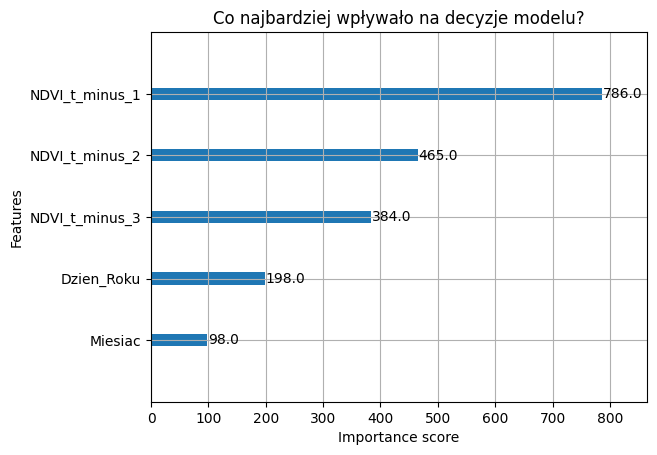

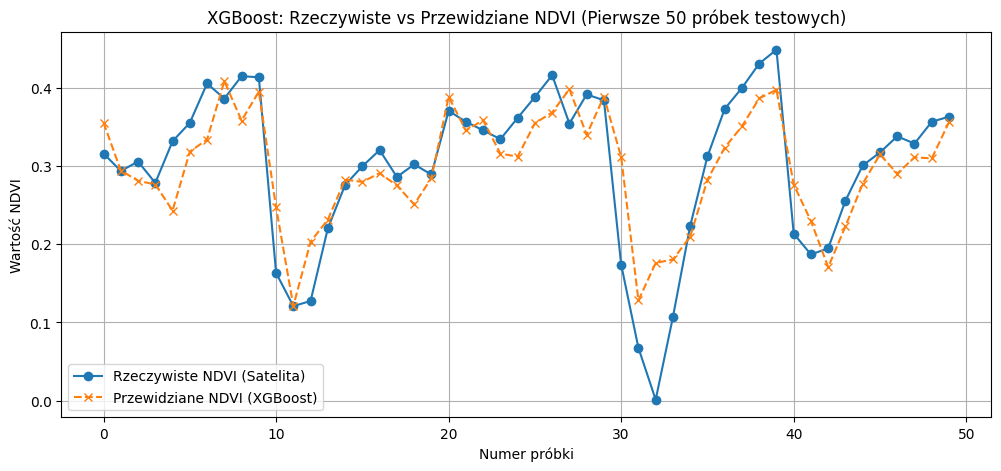

In [22]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Inicjalizacja modelu z podstawowymi (ale rozsądnymi) parametrami
model_xgb = xgb.XGBRegressor(
    n_estimators=100,      # Liczba drzew decyzyjnych (iteracji)
    learning_rate=0.1,     # Szybkość uczenia (krok)
    max_depth=5,           # Maksymalna głębokość pojedynczego drzewa
    random_state=42,       # Ziarno losowości (żeby wyniki były powtarzalne)
    n_jobs=-1              # Użyj wszystkich rdzeni procesora do przyspieszenia obliczeń
)

# 2. Trenowanie (Faza uczenia) na danych do lutego 2026
print("🧠 Trwa trenowanie modelu XGBoost...")
model_xgb.fit(X_train, y_train)
print("✅ Model wytrenowany!\n")

# 3. Predykcja (Testowanie na danych od marca 2026, których model nie widział)
y_pred = model_xgb.predict(X_test)

# 4. Ewaluacja modelu (Jak dobrze nam poszło?)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("📊 WYNIKI MODELU NA ZBIORZE TESTOWYM:")
print(f"Średni błąd bezwzględny (MAE): {mae:.3f}")
print(f"Błąd średniokwadratowy (RMSE): {rmse:.3f}")
print(f"Współczynnik R^2: {r2:.3f}\n")

# ==========================================
# WIZUALIZACJE (Opcjonalne, ale bardzo przydatne!)
# ==========================================

# Wykres 1: Jakie cechy były dla modelu najważniejsze?
plt.figure(figsize=(8, 5))
xgb.plot_importance(model_xgb, importance_type='weight', max_num_features=5, title='Co najbardziej wpływało na decyzje modelu?')
plt.show()

# Wykres 2: Porównanie Rzeczywistość vs Predykcja (Dla małej próbki, np. pierwszych 50 dni testowych)
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:50], label='Rzeczywiste NDVI (Satelita)', marker='o', linestyle='-')
plt.plot(y_pred[:50], label='Przewidziane NDVI (XGBoost)', marker='x', linestyle='--')
plt.title("XGBoost: Rzeczywiste vs Przewidziane NDVI (Pierwsze 50 próbek testowych)")
plt.xlabel("Numer próbki")
plt.ylabel("Wartość NDVI")
plt.legend()
plt.grid(True)
plt.show()

Trenowanie modeli...

🌲 WYNIKI - Random Forest:
MAE: 0.044 | R^2: 0.704

🧠 WYNIKI - Sieć Neuronowa (MLP):
MAE: 0.062 | R^2: 0.467



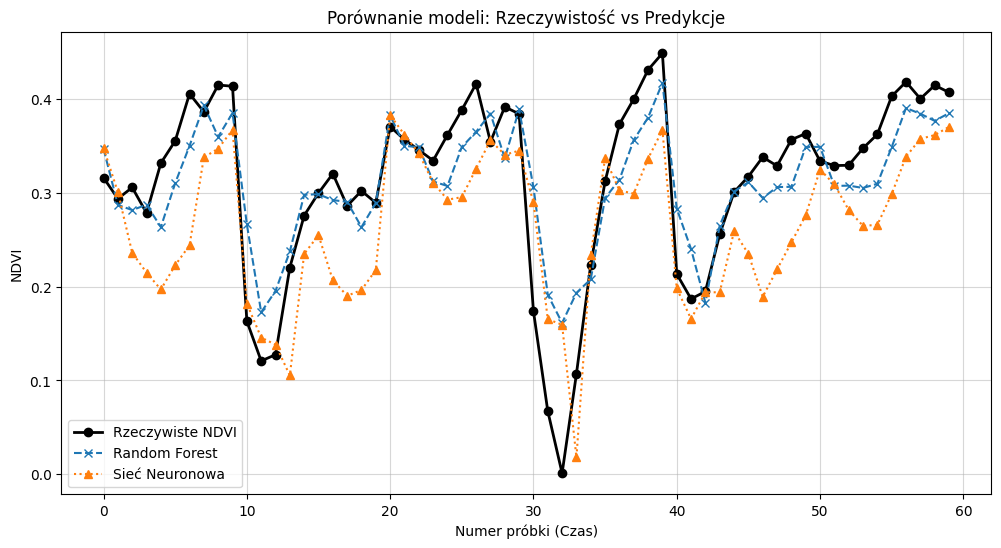

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

print("Trenowanie modeli...\n")

# ==========================================
# MODEL 1: LAS LOSOWY (Random Forest)
# ==========================================
model_rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("🌲 WYNIKI - Random Forest:")
print(f"MAE: {mae_rf:.3f} | R^2: {r2_rf:.3f}\n")

# ==========================================
# MODEL 2: SIEĆ NEURONOWA (MLP)
# ==========================================
# UWAGA: Sieci neuronowe są bardzo wrażliwe na skalę danych. 
# Musimy najpierw spłaszczyć nasze cechy do podobnych zakresów za pomocą scalera.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Tworzymy sieć z dwiema ukrytymi warstwami (po 50 "neuronów" każda)
model_nn = MLPRegressor(hidden_layer_sizes=(50, 50, 50), max_iter=100000, random_state=42)
model_nn.fit(X_train_scaled, y_train)
y_pred_nn = model_nn.predict(X_test_scaled)

mae_nn = mean_absolute_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print("🧠 WYNIKI - Sieć Neuronowa (MLP):")
print(f"MAE: {mae_nn:.3f} | R^2: {r2_nn:.3f}\n")

# ==========================================
# WIZUALIZACJA PORÓWNAWCZA
# ==========================================
plt.figure(figsize=(12, 6))
# Wyświetlamy np. pierwsze 60 próbek ze zbioru testowego
probki = 60
plt.plot(y_test.values[:probki], label='Rzeczywiste NDVI', marker='o', color='black', linewidth=2)
plt.plot(y_pred_rf[:probki], label='Random Forest', marker='x', linestyle='--')
plt.plot(y_pred_nn[:probki], label='Sieć Neuronowa', marker='^', linestyle=':')

plt.title("Porównanie modeli: Rzeczywistość vs Predykcje")
plt.xlabel("Numer próbki (Czas)")
plt.ylabel("NDVI")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()